In [1]:
import os
print(os.getcwd())

D:\ACM-SIGAI-Recruitment-2026\Day-05-Tree-Models


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)

print(dt_accuracy)

1.0


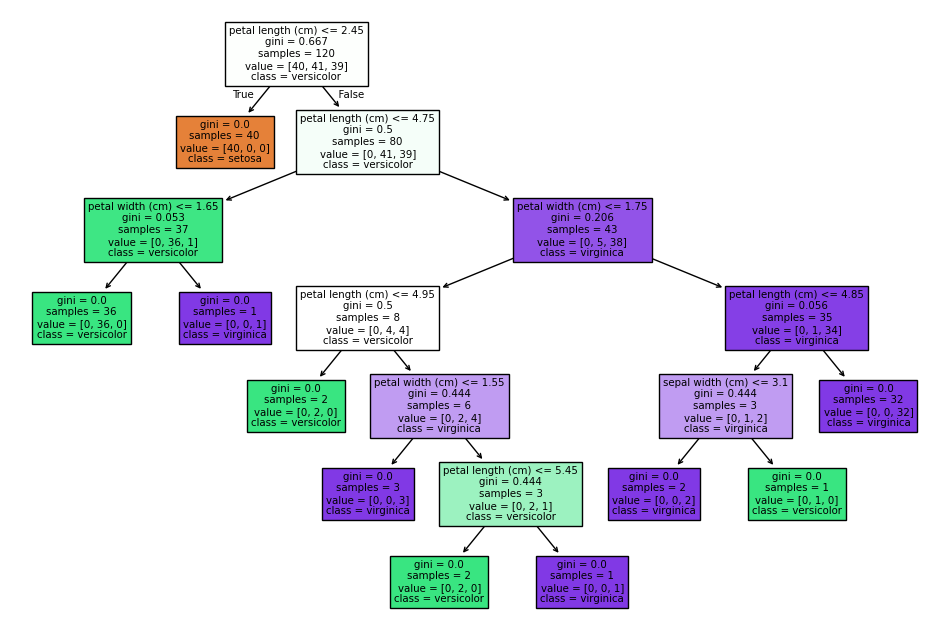

In [5]:
from sklearn import tree

plt.figure(figsize=(12,8))

tree.plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print(rf_accuracy)

1.0


In [7]:
importance = pd.DataFrame({

    "Feature":iris.feature_names,

    "Importance":rf_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,petal length (cm),0.439994
3,petal width (cm),0.421522
0,sepal length (cm),0.108098
1,sepal width (cm),0.030387


In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_prediction = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)

print(xgb_accuracy)

1.0


In [10]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]

})

results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,XGBoost,1.0


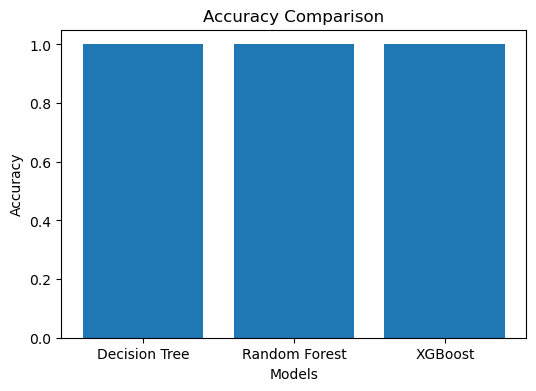

In [11]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.show()